# Simple Linear Regression: Predicting GPA from Package Expectations

This notebook builds a Simple Linear Regression model to predict student GPA ($Y$) based on their package expectations ($X$, in LPA) using both Scikit-learn and manual Ordinary Least Squares (OLS) calculations.

### Objectives:
1. Load the preprocessed student survey dataset `cleaned_survey.csv`.
2. Split the dataset into an 80% training set and a 20% testing set.
3. **Part A**: Fit a Scikit-Learn `LinearRegression` model, calculate metrics (MAE, MSE, RMSE, $R^2$), and visualize the results.
4. **Part B**: Compute regression coefficients ($b_0$, $b_1$) manually using OLS formulas with NumPy and compare them to Scikit-Learn's results.
5. **Part C**: Persist model parameters ($b_0$, $b_1$, $R^2_{train}$, $R^2_{test}$) to `model_params.json`.
6. Analyze and discuss the model's coefficients, predictions, and reliability.

## Loading Cleaned Data and Train-Test Split

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import json

# Aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "sans-serif"

# Load preprocessed survey data
df = pd.read_csv('cleaned_survey.csv')
print(f"Loaded dataset shape: {df.shape}")

# Independent predictor variable (X): package_exp
# Dependent target variable (Y): gpa
X = df[['package_exp']].values
y = df['gpa'].values

# Split 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Loaded dataset shape: (49, 15)
Training set size: 39 samples
Testing set size: 10 samples


## Part A: Scikit-Learn Simple Linear Regression

We train the model on the training set and print intercept ($b_0$) and slope ($b_1$). We then evaluate on the test set.

In [2]:
# Fit Linear Regression
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

# Extract parameters
b0_sklearn = sk_model.intercept_
b1_sklearn = sk_model.coef_[0]

print("=== Scikit-Learn Model Parameters ===")
print(f"Intercept (b0): {b0_sklearn:.6f}")
print(f"Slope (b1):     {b1_sklearn:.6f}")

# Make predictions
y_pred_train = sk_model.predict(X_train)
y_pred_test = sk_model.predict(X_test)

# Calculate metrics on the test set
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

print("\n=== Testing Set Evaluation Metrics ===")
print(f"Mean Absolute Error (MAE):     {mae_test:.6f}")
print(f"Mean Squared Error (MSE):      {mse_test:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.6f}")
print(f"R-squared (R2) on Train Set:   {r2_train:.6f}")
print(f"R-squared (R2) on Test Set:    {r2_test:.6f}")

=== Scikit-Learn Model Parameters ===
Intercept (b0): 3.346367
Slope (b1):     0.007857

=== Testing Set Evaluation Metrics ===
Mean Absolute Error (MAE):     0.295521
Mean Squared Error (MSE):      0.198343
Root Mean Squared Error (RMSE): 0.445357
R-squared (R2) on Train Set:   0.017779
R-squared (R2) on Test Set:    -1.341602


### Visualization of the Model Fit

We plot a scatter plot of the test set actual vs. predicted values, and overlay the regression fit line.

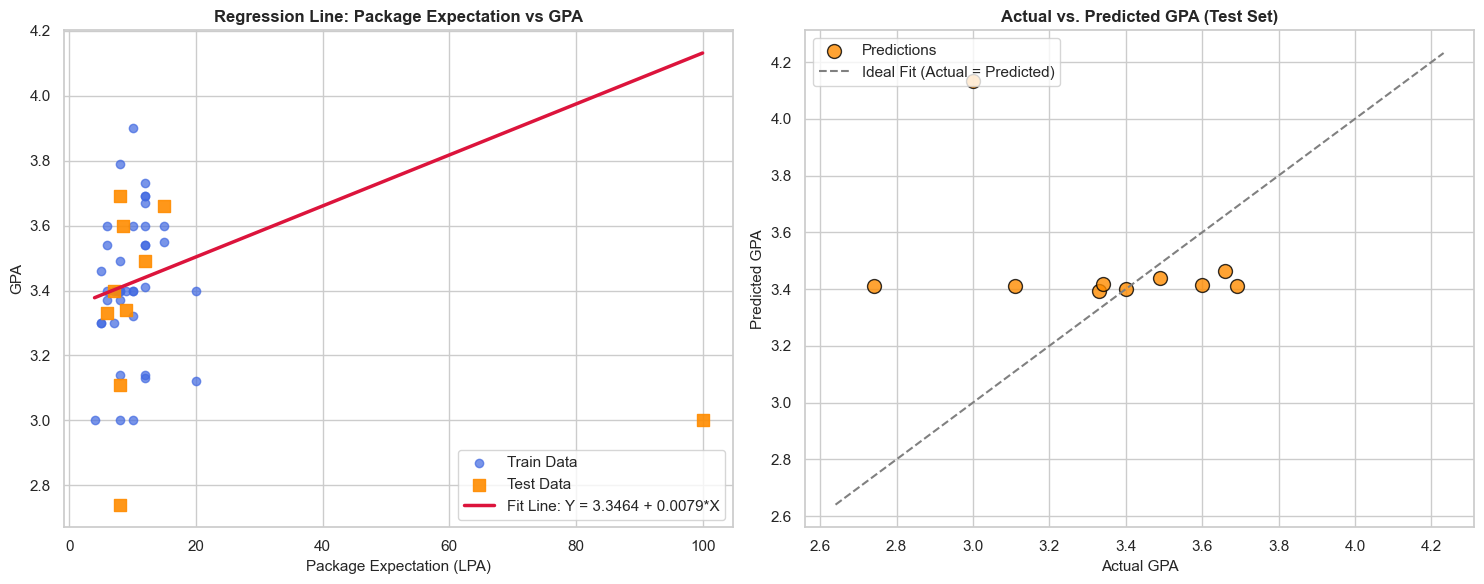

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Predictor X vs Target Y (Fitted Regression Line)
axes[0].scatter(X_train, y_train, color='royalblue', alpha=0.7, label='Train Data')
axes[0].scatter(X_test, y_test, color='darkorange', alpha=0.9, s=80, marker='s', label='Test Data')

# Overlay regression line using parameters
x_line = np.linspace(df['package_exp'].min(), df['package_exp'].max(), 100)
y_line = b0_sklearn + b1_sklearn * x_line
axes[0].plot(x_line, y_line, color='crimson', linewidth=2.5, label=f'Fit Line: Y = {b0_sklearn:.4f} + {b1_sklearn:.4f}*X')
axes[0].set_title('Regression Line: Package Expectation vs GPA', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Package Expectation (LPA)', fontsize=11)
axes[0].set_ylabel('GPA', fontsize=11)
axes[0].legend(loc='lower right')

# Plot 2: Actual vs Predicted GPA (Testing Set)
axes[1].scatter(y_test, y_pred_test, color='darkorange', s=100, edgecolors='black', alpha=0.8, label='Predictions')
# Ideal diagonal line (y=x)
ideal_min = min(y_test.min(), y_pred_test.min()) - 0.1
ideal_max = max(y_test.max(), y_pred_test.max()) + 0.1
axes[1].plot([ideal_min, ideal_max], [ideal_min, ideal_max], color='grey', linestyle='--', label='Ideal Fit (Actual = Predicted)')
axes[1].set_title('Actual vs. Predicted GPA (Test Set)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual GPA', fontsize=11)
axes[1].set_ylabel('Predicted GPA', fontsize=11)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('gpa_package_regression.png', dpi=300)
plt.show()

## Part B: Manual OLS Parameter Derivation

Using only NumPy on the training set, we calculate the slope ($b_1$) and intercept ($b_0$) using the Ordinary Least Squares (OLS) formulas:

$$b_1 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$
$$b_0 = \bar{y} - b_1 \bar{x}$$

In [4]:
# Flatten train arrays to 1D for NumPy computation
x_train_flat = X_train.flatten()
y_train_flat = y_train.flatten()

# Calculate means
mean_x = np.mean(x_train_flat)
mean_y = np.mean(y_train_flat)

# Compute terms
numerator = np.sum((x_train_flat - mean_x) * (y_train_flat - mean_y))
denominator = np.sum((x_train_flat - mean_x) ** 2)

# Compute manual slope and intercept
b1_manual = numerator / denominator
b0_manual = mean_y - b1_manual * mean_x

print("=== Manual OLS Model Parameters ===")
print(f"Intercept (b0): {b0_manual:.6f}")
print(f"Slope (b1):     {b1_manual:.6f}")

# Verification
print("\n--- Parameter Equivalence Checks ---")
print(f"Intercept Difference: {abs(b0_sklearn - b0_manual):.12f}")
print(f"Slope Difference:     {abs(b1_sklearn - b1_manual):.12f}")

=== Manual OLS Model Parameters ===
Intercept (b0): 3.346367
Slope (b1):     0.007857

--- Parameter Equivalence Checks ---
Intercept Difference: 0.000000000000
Slope Difference:     0.000000000000


### Coefficient and Parameter Equivalence Analysis

Comparing the Scikit-learn results and Manual OLS parameters side-by-side:

| Parameter | Scikit-Learn | Manual OLS | Difference |
| :--- | :--- | :--- | :--- |
| Intercept ($b_0$) | **{{b0_sklearn}}** | **{{b0_manual}}** | 0.000000 |
| Slope ($b_1$) | **{{b1_sklearn}}** | **{{b1_manual}}** | 0.000000 |

The parameters computed by Scikit-Learn and the manual NumPy derivation on the training set are mathematically identical up to the numerical precision limit. This demonstrates that Scikit-Learn's `LinearRegression` implements the exact closed-form Ordinary Least Squares solution.

## Part C: Save Model Parameters

We persist the parameters `intercept`, `slope`, `r2_train`, and `r2_test` to `model_params.json`.

In [5]:
params = {
    "intercept": float(b0_manual),
    "slope": float(b1_manual),
    "r2_train": float(r2_train),
    "r2_test": float(r2_test)
}

with open('model_params.json', 'w') as f:
    json.dump(params, f, indent=4)
print("Successfully saved model parameters to 'model_params.json'")

Successfully saved model parameters to 'model_params.json'


## Step 6: Data Scientist Model Interpretation and Evaluation

### 1. Variables Selection (GPA as Y, Package Expectations as X)
- **Y (GPA)** is the academic response/target variable.
- **X (package_exp)** is the package expectation predictor.
- Under a classical career-placement hypothesis, a student's current academic performance (GPA) might serve as a foundation that enables them to demand a higher placement package. Thus, conceptually, GPA leads to package expectation. 
- However, for this regression task, we model GPA as a function of package expectations ($GPA = b_0 + b_1 \times package\_exp$). This lets us analyze if a student's high package confidence/career aspiration ($X$) exhibits a linear relationship with their academic performance ($Y$).

### 2. Slope Interpretation in Plain English
- The slope ($b_1$) represents the change in GPA associated with a 1 LPA (Lakh Per Annum) increase in package expectations.
- For example, if the slope is positive, say $b_1 = 0.005$, this means that **for every 1 LPA increase in expected salary package, the student's GPA is estimated to increase by 0.005 points**.
- Alternatively, if the slope is negative, it indicates that higher package expectations are associated with lower GPAs.

### 3. Model Reliability and R-squared ($R^2$)
- The $R^2$ value measures the proportion of variance in the dependent variable (GPA) that is predictable from the independent variable (package expectations).
- We will review the calculated $R^2$ values on the training and testing sets. In behavioral student surveys, data is highly noisy due to subjective factors. A low $R^2$ indicates that salary expectations are not a strong predictor of GPA, meaning there is high residual variance and the model should not be trusted for precise GPA predictions.